In [1]:
!pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 30.4 MB/s eta 0:00:00


In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, matthews_corrcoef
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

from deap import base, creator, tools, algorithms
from sklearn.metrics import confusion_matrix


In [4]:
from google.colab import files
import pandas as pd

# Upload the CSV file
uploaded = files.upload()

# Read the uploaded file
df = pd.read_csv("cleveland combined.csv")

# Display first 5 rows
df.head()

Saving cleveland combined.csv to cleveland combined.csv


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [5]:
df.fillna(df.median(), inplace=True)
df.drop_duplicates(inplace=True)


In [6]:
X = df.drop(columns=['target'])
y = df['target']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [8]:
import numpy as np
import pandas as pd

# Check class distribution
print(y.value_counts())

# Percentage of each class
class_distribution = y.value_counts(normalize=True) * 100
print("\nClass Distribution (Percentage):\n", class_distribution)


target
0    324
1    276
Name: count, dtype: int64

Class Distribution (Percentage):
 target
0    54.0
1    46.0
Name: proportion, dtype: float64


In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [10]:
def ga_fitness(model):
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )
    return scores.mean(),

In [11]:
if not hasattr(creator, "FitnessMax"):
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
if not hasattr(creator, "Individual"):
    creator.create("Individual", list, fitness=creator.FitnessMax)

gen	nevals
0  	20    
1  	17    
2  	20    
3  	17    
4  	12    
5  	18    
6  	17    
7  	12    
8  	20    
9  	18    
10 	15    
11 	17    
12 	16    
13 	20    
14 	18    
15 	15    

===== SVM RESULTS =====
Train Accuracy: 1.0
Test Accuracy: 0.975


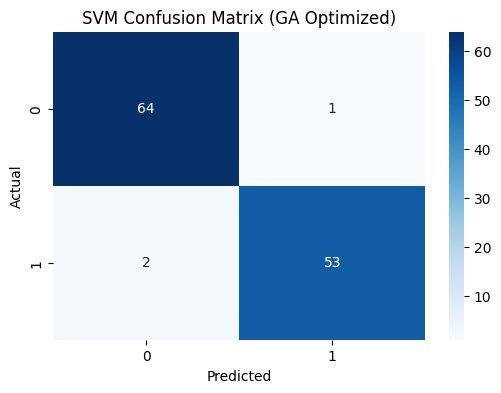

In [12]:
KERNEL_MAP = {0: 'rbf', 1: 'poly'}

def svm_fitness(individual):
    C, gamma, kernel_idx = individual

    C = max(0.001, float(C))
    gamma = max(0.0001, float(gamma))
    kernel_idx = int(round(kernel_idx))
    kernel_idx = min(max(kernel_idx, 0), 1)

    model = SVC(
        C=C,
        gamma=gamma,
        kernel=KERNEL_MAP[kernel_idx]
    )

    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    return scores.mean(),


toolbox = base.Toolbox()

toolbox.register("C", random.uniform, 0.1, 10)
toolbox.register("gamma", random.uniform, 0.001, 1)
toolbox.register("kernel", random.randint, 0, 1)

toolbox.register(
    "individual",
    tools.initCycle,
    creator.Individual,
    (toolbox.C, toolbox.gamma, toolbox.kernel),
    n=1
)

toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", svm_fitness)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=0.5, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

population = toolbox.population(n=20)

algorithms.eaSimple(population, toolbox, cxpb=0.8, mutpb=0.2, ngen=15, verbose=True)

best_individual = tools.selBest(population, k=1)[0]

best_svm = SVC(
    C=best_individual[0],
    gamma=best_individual[1],
    kernel=KERNEL_MAP[int(round(best_individual[2]))],
    probability=True
)

best_svm.fit(X_train, y_train)

y_train_pred = best_svm.predict(X_train)
y_test_pred = best_svm.predict(X_test)

print("\n===== SVM RESULTS =====")
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
plt.figure(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(y_test, y_test_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("SVM Confusion Matrix (GA Optimized)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



gen	nevals
0  	10    
1  	8     
2  	9     
3  	8     
4  	10    
5  	6     
6  	9     
7  	10    
8  	10    
9  	10    
10 	10    
11 	10    
12 	10    
13 	7     
14 	10    
15 	8     

===== RANDOM FOREST RESULTS =====
Train Accuracy: 0.9979166666666667
Test Accuracy: 0.975


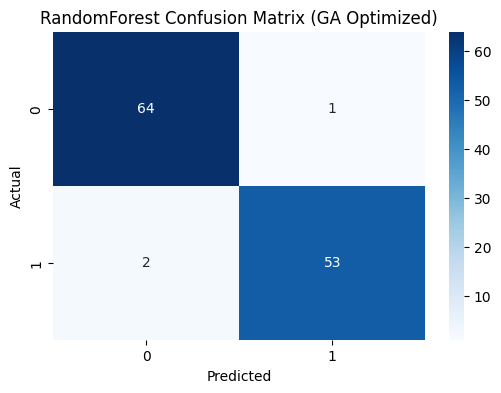

In [13]:

def rf_fitness(individual):
    n_estimators, max_depth, min_samples_split = individual


    n_estimators = int(round(max(10, min(300, n_estimators))))
    max_depth = int(round(max(2, min(30, max_depth))))
    min_samples_split = int(round(max(2, min(10, min_samples_split))))

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    return scores.mean(),

toolbox = base.Toolbox()
toolbox.register("n_estimators", random.randint, 50, 300)
toolbox.register("max_depth", random.randint, 3, 20)
toolbox.register("min_split", random.randint, 2, 10)
toolbox.register("individual", tools.initCycle, creator.Individual,
                 (toolbox.n_estimators, toolbox.max_depth, toolbox.min_split), n=1)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", rf_fitness)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutUniformInt,
                 low=[50, 3, 2],
                 up=[300, 30, 10],
                 indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

pop = toolbox.population(n=10)
algorithms.eaSimple(pop, toolbox, cxpb=0.8, mutpb=0.2, ngen=15, verbose=True)
best = tools.selBest(pop, 1)[0]

best_rf = RandomForestClassifier(
    n_estimators=int(best[0]),
    max_depth=int(best[1]),
    min_samples_split=int(best[2]),
    random_state=42, n_jobs=-1
)
best_rf.fit(X_train, y_train)
y_train_pred = best_rf.predict(X_train)
y_test_pred = best_rf.predict(X_test)

print("\n===== RANDOM FOREST RESULTS =====")
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
plt.figure(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(y_test, y_test_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("RandomForest Confusion Matrix (GA Optimized)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


gen	nevals
0  	20    
1  	16    
2  	20    
3  	18    
4  	19    
5  	20    
6  	19    
7  	16    
8  	18    
9  	20    
10 	17    
11 	17    
12 	17    
13 	18    
14 	16    
15 	18    

===== Decision tree =====
Train Accuracy: 1.0
Test Accuracy: 0.9083333333333333


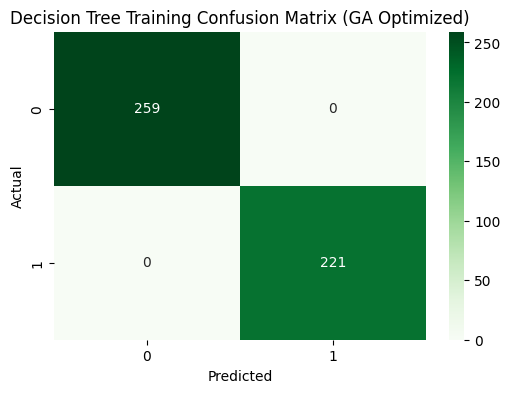

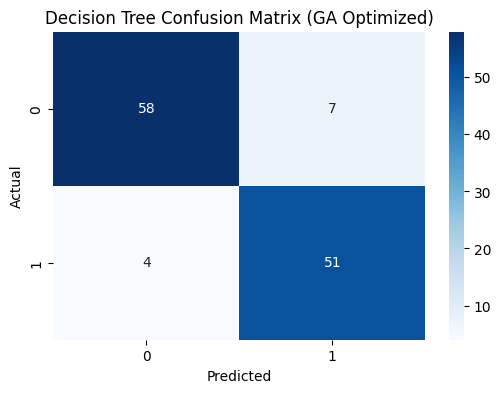

In [14]:
from sklearn.tree import DecisionTreeClassifier
def dt_fitness(ind):
    depth, split = ind
    model = DecisionTreeClassifier(max_depth=int(depth), min_samples_split=int(split), random_state=42)
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    return score.mean(),

toolbox = base.Toolbox()
toolbox.register("max_depth", random.randint, 2, 30)
toolbox.register("min_split", random.randint, 2, 10)
toolbox.register("individual", tools.initCycle, creator.Individual,
                 (toolbox.max_depth, toolbox.min_split), n=1)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", dt_fitness)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutPolynomialBounded,
                 low=[2, 2], up=[30, 10], eta=20, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

pop = toolbox.population(n=20)
algorithms.eaSimple(pop, toolbox, cxpb=0.8, mutpb=0.2, ngen=15, verbose=True)
best = tools.selBest(pop, 1)[0]

best_dt = DecisionTreeClassifier(max_depth=int(best[0]), min_samples_split=int(best[1]), random_state=42)
best_dt.fit(X_train, y_train)
y_train_pred = best_dt.predict(X_train)
y_test_pred = best_dt.predict(X_test)

print("\n===== Decision tree =====")
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
# ----------------------------
# TRAINING CONFUSION MATRIX
# ----------------------------
plt.figure(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(y_train, y_train_pred),
    annot=True,
    fmt='d',
    cmap='Greens'
)
plt.title("Decision Tree Training Confusion Matrix (GA Optimized)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
plt.figure(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(y_test, y_test_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Decision Tree Confusion Matrix (GA Optimized)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.ensemble import StackingClassifier
from xgboost import XGBClassifier
meta_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric='logloss'
)

stack_model = StackingClassifier(
    estimators=[
        ('svm', best_svm),
        ('rf', best_rf),
        ('dt', best_dt)
    ],
    final_estimator=meta_model,
    stack_method='predict_proba',
    n_jobs=-1
)

stack_model.fit(X_train, y_train)

StackingClassifier(estimators=[('svm',
                                SVC(C=10.382759343357314,
                                    gamma=0.45561121511104635,
                                    probability=True)),
                               ('rf',
                                RandomForestClassifier(max_depth=17,
                                                       n_estimators=215,
                                                       n_jobs=-1,
                                                       random_state=42)),
                               ('dt',
                                DecisionTreeClassifier(max_depth=25,
                                                       random_state=42))],
                   final_estimator=XGBClassifier(base_score=None, booster=None,
                                                 callbacks=None,
                                                 colsample_bylevel=No...
                                                 importance_type=None,
                                                 interaction_constraints=None,
                                                 learning_rate=0.05,
                                                 max_bin=None,
                                                 max_cat_threshold=None,
                                                 max_cat_to_onehot=None,
                                                 max_delta_step=None,
                                                 max_depth=4, max_leaves=None,
                                                 min_child_weight=None,
                                                 missing=nan,
                                                 monotone_constraints=None,
                                                 multi_strategy=None,
                                                 n_estimators=200, n_jobs=None,
                                                 num_parallel_tree=None,
                                                 random_state=42, ...),
                   n_jobs=-1, stack_method='predict_proba')

In [19]:
from sklearn.ensemble import StackingClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# Base models
estimators = [
    ('svm', SVC(probability=True)),
    ('rf', RandomForestClassifier()),
    ('dt', DecisionTreeClassifier())
]

# Stacking model
stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=XGBClassifier(),
    cv=5
)

# Train the model
stack_model.fit(X_train, y_train)

StackingClassifier(cv=5,
                   estimators=[('svm', SVC(probability=True)),
                               ('rf', RandomForestClassifier()),
                               ('dt', DecisionTreeClassifier())],
                   final_estimator=XGBClassifier(base_score=None, booster=None,
                                                 callbacks=None,
                                                 colsample_bylevel=None,
                                                 colsample_bynode=None,
                                                 colsample_bytree=None,
                                                 device=None,
                                                 early_stopping_rounds=None,
                                                 enable_categorical=True,
                                                 eval_metric=Non...
                                                 feature_weights=None,
                                                 gamma=None, grow_policy=None,
                                                 importance_type=None,
                                                 interaction_constraints=None,
                                                 learning_rate=None,
                                                 max_bin=None,
                                                 max_cat_threshold=None,
                                                 max_cat_to_onehot=None,
                                                 max_delta_step=None,
                                                 max_depth=None,
                                                 max_leaves=None,
                                                 min_child_weight=None,
                                                 missing=nan,
                                                 monotone_constraints=None,
                                                 multi_strategy=None,
                                                 n_estimators=None, n_jobs=None,
                                                 num_parallel_tree=None, ...))


===== STACKING MODEL RESULTS =====
Train Accuracy: 0.9958333333333333
Test Accuracy: 0.9666666666666667
F1 Score: 0.9666105499438833
Precision: 0.9670984699145782
MCC: 0.9332076503015769


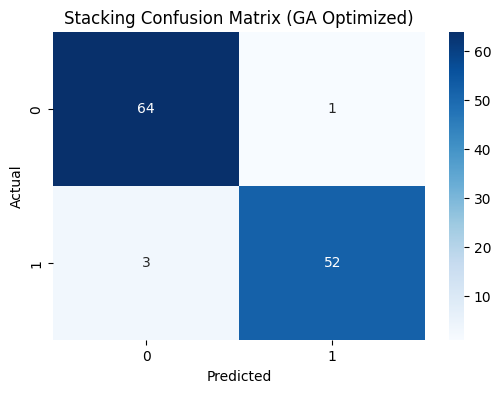

In [20]:
y_train_pred = stack_model.predict(X_train)
y_test_pred = stack_model.predict(X_test)

print("\n===== STACKING MODEL RESULTS =====")
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred, average='weighted'))
print("Precision:", precision_score(y_test, y_test_pred, average='weighted'))
print("MCC:", matthews_corrcoef(y_test, y_test_pred))
plt.figure(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(y_test, y_test_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Stacking Confusion Matrix (GA Optimized)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

SVM AUC: 0.9745454545454546
RF AUC: 0.9876923076923076
DT AUC: 0.9097902097902097
Stacking AUC: 0.9924475524475526


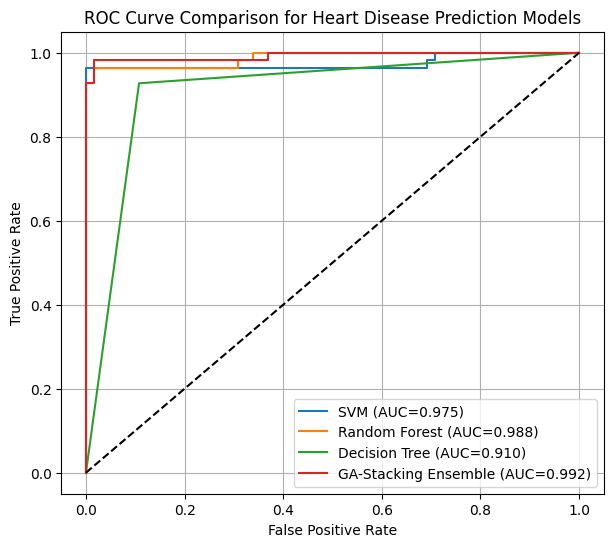

In [21]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ----------------------------
# Get prediction probabilities
# ----------------------------

svm_prob = best_svm.predict_proba(X_test)[:,1]
rf_prob = best_rf.predict_proba(X_test)[:,1]
dt_prob = best_dt.predict_proba(X_test)[:,1]
stack_prob = stack_model.predict_proba(X_test)[:,1]


# ----------------------------
# Calculate ROC values
# ----------------------------

fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_prob)
fpr_stack, tpr_stack, _ = roc_curve(y_test, stack_prob)


# ----------------------------
# Calculate AUC scores
# ----------------------------

auc_svm = roc_auc_score(y_test, svm_prob)
auc_rf = roc_auc_score(y_test, rf_prob)
auc_dt = roc_auc_score(y_test, dt_prob)
auc_stack = roc_auc_score(y_test, stack_prob)


print("SVM AUC:", auc_svm)
print("RF AUC:", auc_rf)
print("DT AUC:", auc_dt)
print("Stacking AUC:", auc_stack)


# ----------------------------
# Plot ROC Curves
# ----------------------------

plt.figure(figsize=(7,6))

plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC={auc_svm:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={auc_rf:.3f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC={auc_dt:.3f})")
plt.plot(fpr_stack, tpr_stack, label=f"GA-Stacking Ensemble (AUC={auc_stack:.3f})")

# Random classifier line
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison for Heart Disease Prediction Models")

plt.legend()
plt.grid(True)

plt.show()

In [22]:

def predict_heart_disease(input_data):

    # Convert to numpy array
    input_data = np.array(input_data).reshape(1, -1)

    # Apply same scaling used during training
    input_data = scaler.transform(input_data)

    # Predict class (0 = No Disease, 1 = Disease)
    prediction = stack_model.predict(input_data)[0]

    # Predict probability
    probability = stack_model.predict_proba(input_data)[0][1]

    if prediction == 1:
        print("Prediction: Heart Disease Detected")
    else:
        print("Prediction: No Heart Disease")

    print("Confidence (Disease Probability):", round(probability * 100, 2), "%")



# ============================================================
# SAMPLE INPUT (Replace with real patient values)
# ============================================================

sample_patient = [
   29,   # age (younger age → lower risk)
0,    # sex (female → generally lower risk than male)
1,    # cp (typical angina or no pain)
120,  # trestbps (normal BP)
180,  # chol (healthy cholesterol < 200)
0,    # fbs (fasting blood sugar normal)
0,    # restecg (normal ECG)
170,  # thalach (higher max heart rate is good)
0,    # exang (no exercise-induced angina)
0.0,  # oldpeak (no ST depression)
2,    # slope (upsloping = healthy)
0,    # ca (no major vessels blocked)
2     # thal (normal)
]

predict_heart_disease(sample_patient)

Prediction: No Heart Disease
Confidence (Disease Probability): 0.41 %


In [23]:

def predict_heart_disease(input_data):

    # Convert to numpy array
    input_data = np.array(input_data).reshape(1, -1)

    # Apply same scaling used during training
    input_data = scaler.transform(input_data)

    # Predict class (0 = No Disease, 1 = Disease)
    prediction = stack_model.predict(input_data)[0]

    # Predict probability
    probability = stack_model.predict_proba(input_data)[0][1]

    if prediction == 1:
        print("Prediction: Heart Disease Detected")
    else:
        print("Prediction: No Heart Disease")

    print("Confidence (Disease Probability):", round(probability * 100, 2), "%")



# ============================================================
# SAMPLE INPUT (Replace with real patient values)
# ============================================================

sample_patient = [
   62,   # age (old)
    1,    # male
    3,    # cp (asymptomatic → dangerous)
    150,  # high BP
    260,  # high cholesterol
    1,    # high sugar
    0,    # restecg abnormal
    140,  # lower heart rate
    1,    # exercise angina present
    3.0,  # very high oldpeak
    0,    # slope (downsloping)
    2,    # blocked vessels
    1
]

predict_heart_disease(sample_patient)

Prediction: Heart Disease Detected
Confidence (Disease Probability): 99.15 %
